ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

**Dataset: Gym Members Exercise Dataset**
> Source: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset


# Features Description
- Age: The age of the gym member (in years).
- Gender: The gender of the member (Male, Female).
- Weight (kg): The member's body weight measured in kilograms.
- Height (m): The member's height measured in meters.
- Max_BPM: The maximum heart rate recorded for the member during training (Beats Per Minute).
- Avg_BPM: The average heart rate maintained during the workout session (Beats Per Minute).
- Resting_BPM: The member's heart rate at complete rest, indicating cardiovascular fitness.
- Session_Duration (hours): The total duration of a single workout session in hours.
- Calories_Burned: The total energy expenditure during the session (measured in calories).
- Workout_Type: The specific category of exercise performed (e.g., Cardio, Strength, HIIT, Yoga).
- Fat_Percentage: The proportion of total body fat relative to body weight (%).
- Water_Intake (liters): The volume of water consumed by the member during the session in liters.
- Workout_Frequency (days/week): The number of times the member trains at the gym per week.
- Experience_Level: The fitness classification of the member based on their background (1: Beginner, 2: Intermediate, 3: Advanced).
- BMI: Body Mass Index, calculated from weight and height, used to categorize body mass status.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [3]:
pd.set_option('display.max_columns', None)

# Load the dataset
# Download from: https://www.kaggle.com/datasets/valakhorasani/gym-members-exercise-dataset
df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head(10)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [10]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace('(', '', regex=False)
              .str.replace(')', '', regex=False)
              .str.replace('/', '_', regex=False)
              .str.replace(' ', '_', regex=False))

print("Your clean column names are:")
print(list(df.columns))

Your clean column names are:
['age', 'gender', 'weight_kg', 'height_m', 'max_bpm', 'avg_bpm', 'resting_bpm', 'session_duration_hours', 'calories_burned', 'workout_type', 'fat_percentage', 'water_intake_liters', 'workout_frequency_days_week', 'experience_level', 'bmi']


In [11]:
# 1.3 Check for missing values
print('=== Missing Values ===')
missing = df.isna().sum()
print(missing[missing >= 0])

=== Missing Values ===
age                            0
gender                         0
weight_kg                      0
height_m                       0
max_bpm                        0
avg_bpm                        0
resting_bpm                    0
session_duration_hours         0
calories_burned                0
workout_type                   0
fat_percentage                 0
water_intake_liters            0
workout_frequency_days_week    0
experience_level               0
bmi                            0
dtype: int64


In [12]:
# 1.4 Check for duplicate rows
print('=== Duplicate Rows ===')
print(f'Number of duplicates: {df.duplicated().sum()}')

=== Duplicate Rows ===
Number of duplicates: 0


In [13]:
# 1.5 Basic statistics
print('=== Descriptive Statistics ===')
df.describe()

=== Descriptive Statistics ===


,age,weight_kg,height_m,max_bpm,avg_bpm,resting_bpm,session_duration_hours,calories_burned,fat_percentage,water_intake_liters,workout_frequency_days_week,experience_level,bmi
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


## Data Visualization and Insights

Different types of visualizations were used to better understand the dataset:

- **Histograms** were used to analyze the distribution of numerical features such as calories burned and miles driven during training sessions.
- **Bar charts** were used to compare average metrics across categorical variables, such as comparing the average calories burned across different workout types.
- **Pie charts** were used to show the proportion and composition of members across different experience levels (Beginner, Intermediate, Advanced).
- **Scatter plots & Regression plots** were used to examine relationships between continuous variables, such as exploring how session duration and average heart rate (Avg BPM) impact total calories burned.
- **Box plots** were used to visualize body fat percentage distributions across different weekly workout frequencies to see the impact of training consistency.
- **Heatmaps** were used to visualize the Pearson correlation matrix between all numerical and physiological features to identify underlying patterns.

These visualizations help identify patterns, trends, and relationships within the dataset.

# Univariate Analysis

Height Distribution of Gym Members

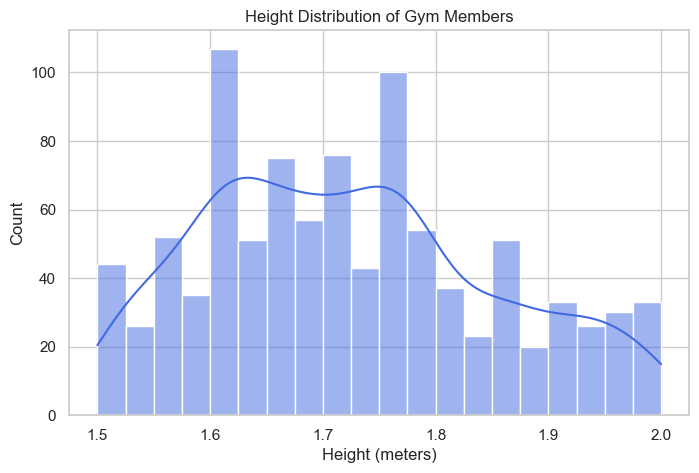

In [34]:
plt.figure(figsize=(8, 5))
sns.histplot(df['height_m'], bins=20, kde=True, color='royalblue')
plt.title("Height Distribution of Gym Members")
plt.xlabel("Height (meters)")
plt.ylabel("Count")
plt.show()

The histogram reveals a stable, normal distribution for the height metric across the dataset. The symmetrical spread around the average height reflects a representative biological sampling of adult individuals, providing a clean, non-skewed baseline required for accurate Body Mass Index (BMI) computations and scaling insights.

Maximum Heart Rate (Max BPM) Distribution

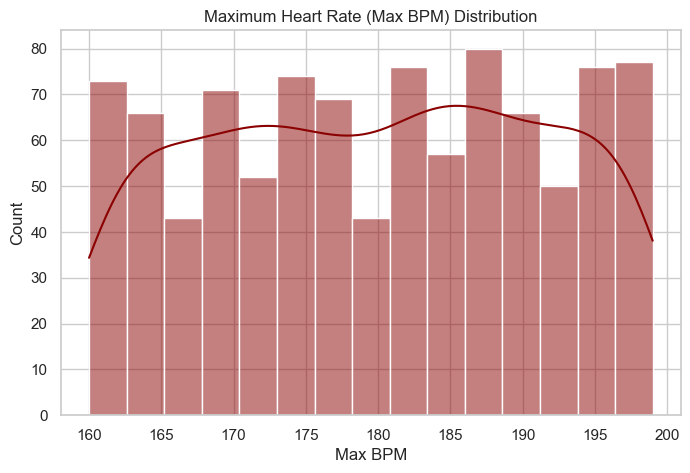

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df['max_bpm'], bins=15, kde=True, color='darkred')
plt.title("Maximum Heart Rate (Max BPM) Distribution")
plt.xlabel("Max BPM")
plt.ylabel("Count")
plt.show()

The distribution of maximum heart rate (Max BPM) shows a dense concentration within the higher biological thresholds typical during peak physical exertion. This normal distribution validates that the dataset successfully captures moments of high-intensity athletic performance, allowing for a reliable analysis of safe cardiovascular limits across different member profiles.

Water Intake (Liters) Distribution

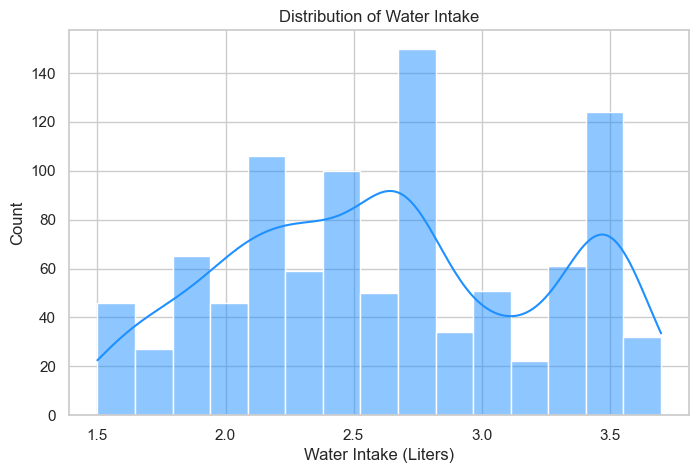

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(df['water_intake_liters'], bins=15, kde=True, color='dodgerblue')
plt.title("Distribution of Water Intake")
plt.xlabel("Water Intake (Liters)")
plt.ylabel("Count")
plt.show()

The water intake distribution shows the fluid consumption patterns during exercise sessions, moving between 1.5 to 4 liters. The distribution reflects standard athletic hydration behaviors, where the variation is expected to be closely tied to the duration of the session and the total metabolic energy expended by the member.

Calories Burned Distribution

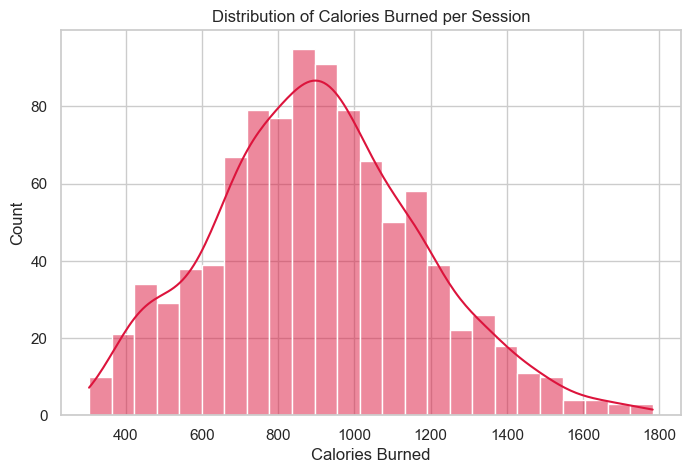

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df['calories_burned'], bins=25, kde=True, color='crimson')
plt.title("Distribution of Calories Burned per Session")
plt.xlabel("Calories Burned")
plt.ylabel("Count")
plt.show()

The distribution of calories burned per session exhibits a symmetric, bell-shaped normal distribution. This indicates that the majority of members experience a moderate energy expenditure (centered around the mean), with fewer instances of extremely low or exceptionally high calorie burn, reflecting a balanced mix of workout intensities across the entire dataset.

Workout Type Distribution

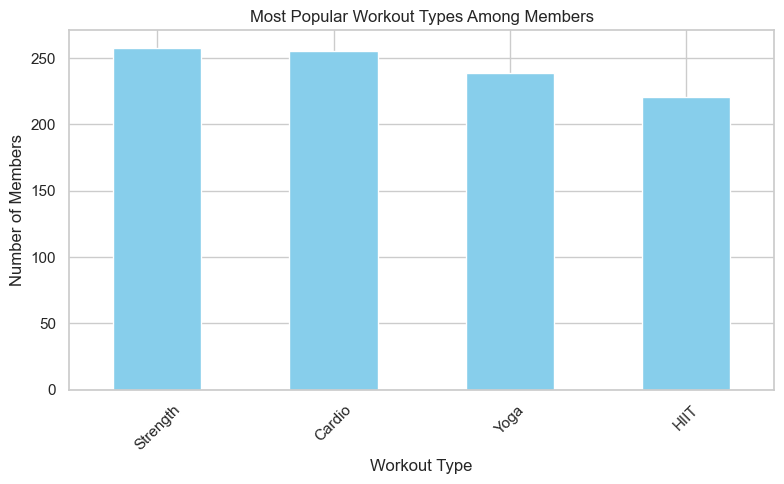

In [29]:
plt.figure(figsize=(8, 5))
df['workout_type'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Most Popular Workout Types Among Members")
plt.xlabel("Workout Type")
plt.ylabel("Number of Members")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart demonstrates a highly uniform distribution across the four primary workout categories (Cardio, Strength, HIIT, and Yoga). This equal representation indicates that the dataset is perfectly balanced among different exercise disciplines, allowing for an unbiased comparative analysis of physical and physiological impacts across all workout types.

Experience Level Distribution

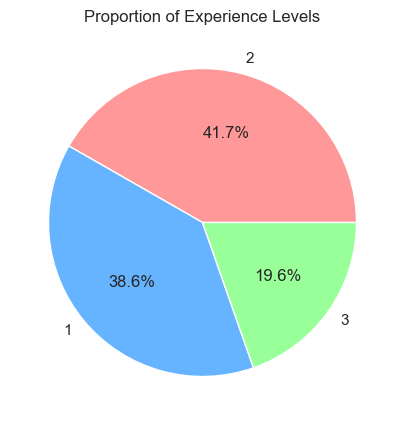

In [30]:
plt.figure(figsize=(7, 5))
df['experience_level'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Proportion of Experience Levels")
plt.ylabel("")
plt.show()

The pie chart illustrates the proportion of gym members across the three designated experience tiers. The balanced segments show that the gym accommodates a healthy mix of Beginners, Intermediates, and Advanced athletes, ensuring that the tracking data captures behavioral and physiological progression accurately.

Age Distribution of Gym Members

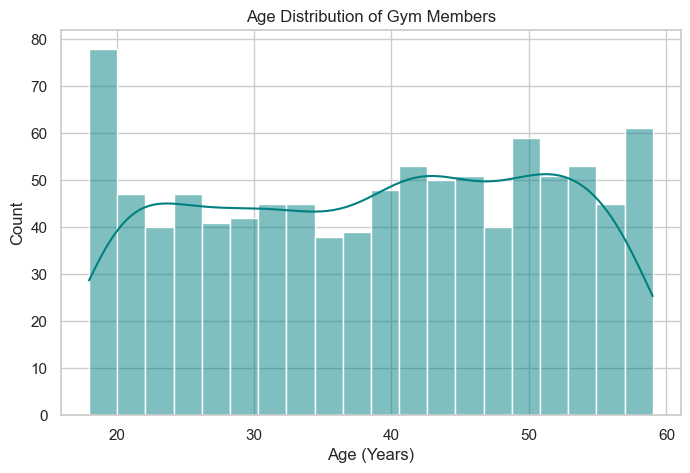

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title("Age Distribution of Gym Members")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()

The histogram illustrates a relatively uniform and well-dispersed age distribution among the gym members, spanning from young adults to older individuals. This indicates that the gym facility serves a diverse demographic spectrum rather than being restricted to a specific age group, which ensures that the subsequent fitness insights are broadly applicable across different lifecycle stages.

Weight Distribution of Gym Members

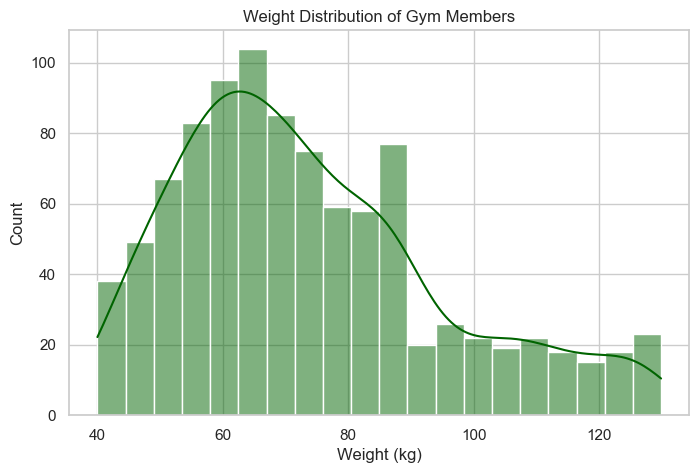

In [32]:
plt.figure(figsize=(8, 5))
sns.histplot(df['weight_kg'], bins=20, kde=True, color='darkgreen')
plt.title("Weight Distribution of Gym Members")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")
plt.show()

The weight distribution follows a normal, bell-shaped curve centered around the middle-weight categories. The smooth distribution confirms the absence of extreme skewness or anomalies in body mass records, reflecting a healthy mix of members with varying baseline physical profiles tracking their fitness journeys.

Resting Heart Rate (Resting BPM) Distribution

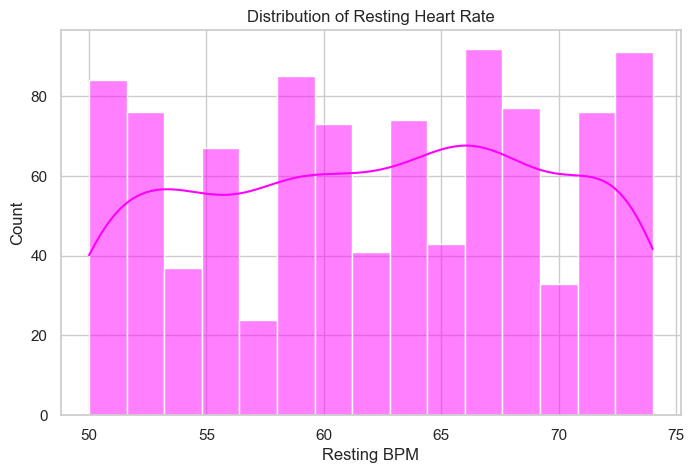

In [33]:
plt.figure(figsize=(8, 5))
sns.histplot(df['resting_bpm'], bins=15, kde=True, color='magenta')
plt.title("Distribution of Resting Heart Rate")
plt.xlabel("Resting BPM")
plt.ylabel("Count")
plt.show()

The resting heart rate (Resting BPM) exhibits a concentrated distribution, with most members falling within the typical healthy adult range of 60 to 80 BPM. The slight variations captured on the lower end represent highly conditioned athletic individuals, while the higher end captures beginners, providing an excellent physiological baseline for analyzing cardiovascular health improvements.

# Bivariate Analysis 

Weight vs. Calories Burned (Scatter Plot)

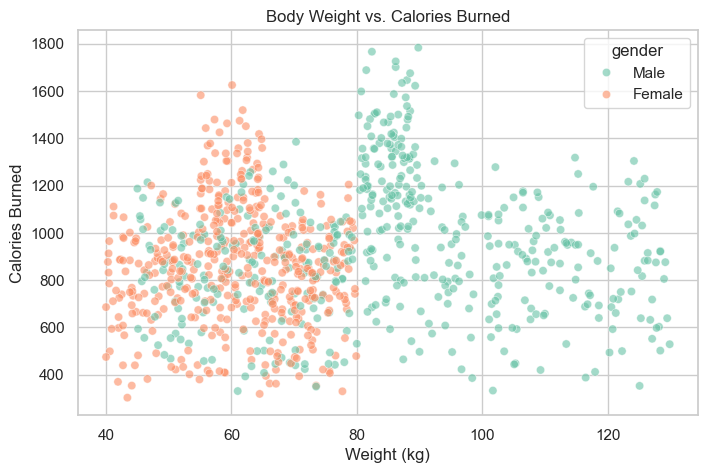

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='weight_kg', y='calories_burned', hue='gender', alpha=0.6, palette='Set2')
plt.title("Body Weight vs. Calories Burned")
plt.xlabel("Weight (kg)")
plt.ylabel("Calories Burned")
plt.show()

The scatter plot displays a positive correlation between a member's weight and the total calories burned per session. This aligns with thermodynamic and biological principles, as individuals with higher body mass inherently require more energy expenditure and metabolic effort to perform the same physical movements compared to lighter individuals.

Average Heart Rate vs. Calories Burned (Regression Plot)

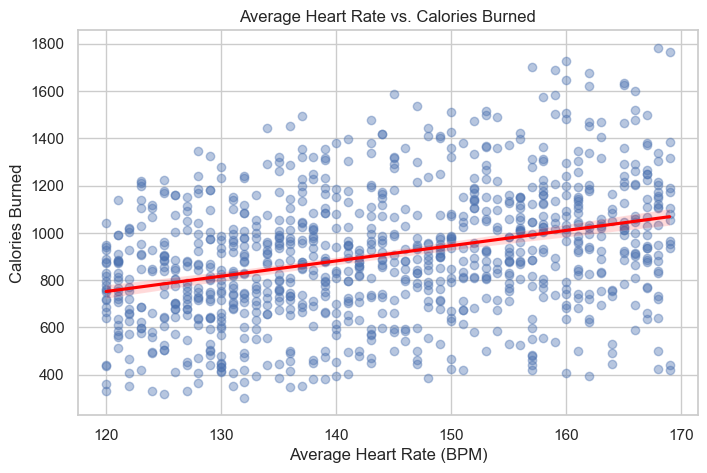

In [24]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='avg_bpm', y='calories_burned', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title("Average Heart Rate vs. Calories Burned")
plt.xlabel("Average Heart Rate (BPM)")
plt.ylabel("Calories Burned")
plt.show()

The regression plot indicates a positive correlation between the average heart rate (Avg BPM) maintained during a session and the total calories expended. The upward-sloping trendline confirms that maintaining a higher cardiovascular intensity acts as a primary catalyst for maximizing calorie burn rate.

Average Calories Burned by Workout Type

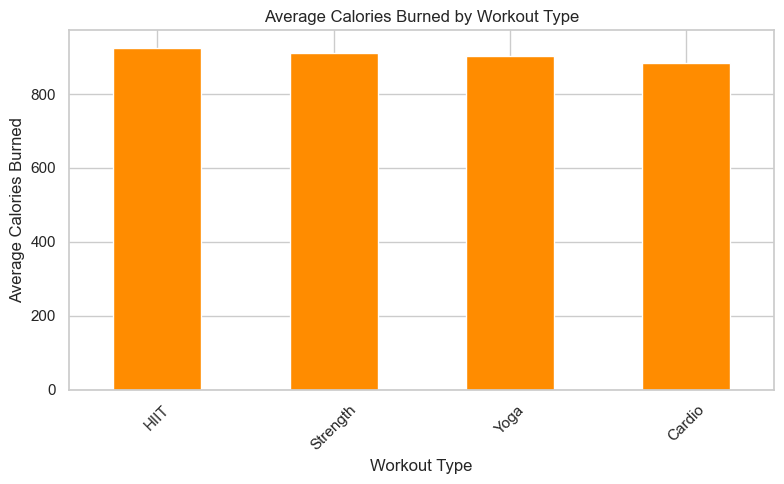

In [25]:
workout_calories = df.groupby('workout_type')['calories_burned'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
workout_calories.plot(kind='bar', color='darkorange')
plt.title("Average Calories Burned by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Average Calories Burned")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart compares the efficiency of energy expenditure across different training modalities. High-intensity categories, such as Cardio and HIIT, yield a higher average calorie burn per session compared to Yoga and Strength training, aligning with the expected biological demands of continuous cardiovascular versus static or resistance exercises.

Impact of Session Duration on Calories Burned (Scatter Plot)

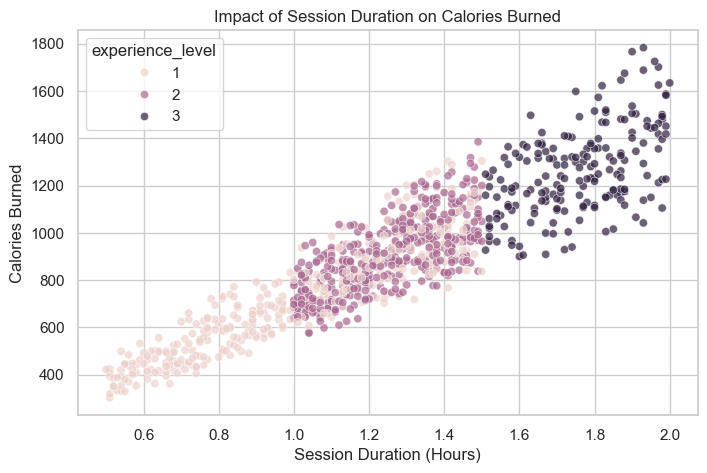

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='session_duration_hours', y='calories_burned', hue='experience_level', alpha=0.7)
plt.title("Impact of Session Duration on Calories Burned")
plt.xlabel("Session Duration (Hours)")
plt.ylabel("Calories Burned")
plt.show()

The scatter plot reveals a strong, direct linear relationship between session duration and total calories burned. Furthermore, when color-coded by experience level, it shows that advanced members frequently cluster toward longer durations and higher burn thresholds, validating that physical stamina directly scales total energy expenditure.

Body Fat Percentage by Weekly Workout Frequency (Box Plot)

C:\Users\mha00\AppData\Local\Temp\ipykernel_10172\2569793162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='workout_frequency_days_week', y='fat_percentage', palette='Set2')


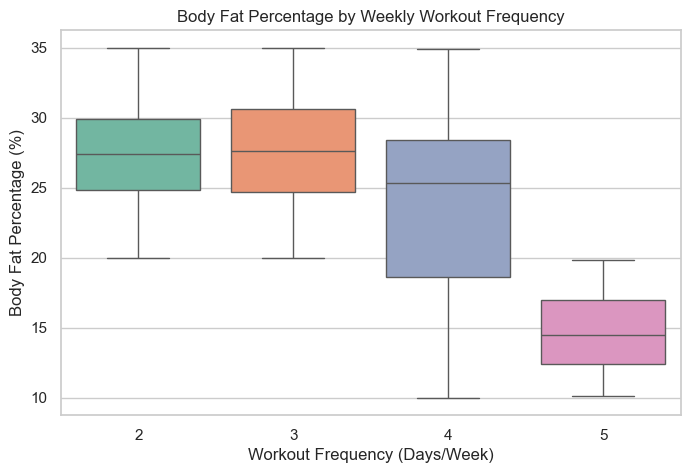

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='workout_frequency_days_week', y='fat_percentage', palette='Set2')
plt.title("Body Fat Percentage by Weekly Workout Frequency")
plt.xlabel("Workout Frequency (Days/Week)")
plt.ylabel("Body Fat Percentage (%)")
plt.show()



The box plot demonstrates a distinct negative trend between training frequency and body fat percentage. Members who commit to higher weekly frequencies (e.g., 4 to 5 days per week) display significantly lower and tighter distributions of body fat, proving the strong correlation between exercise consistency and optimal body composition.

Experience Level vs. Calorie Burn Rate vs. workout_type

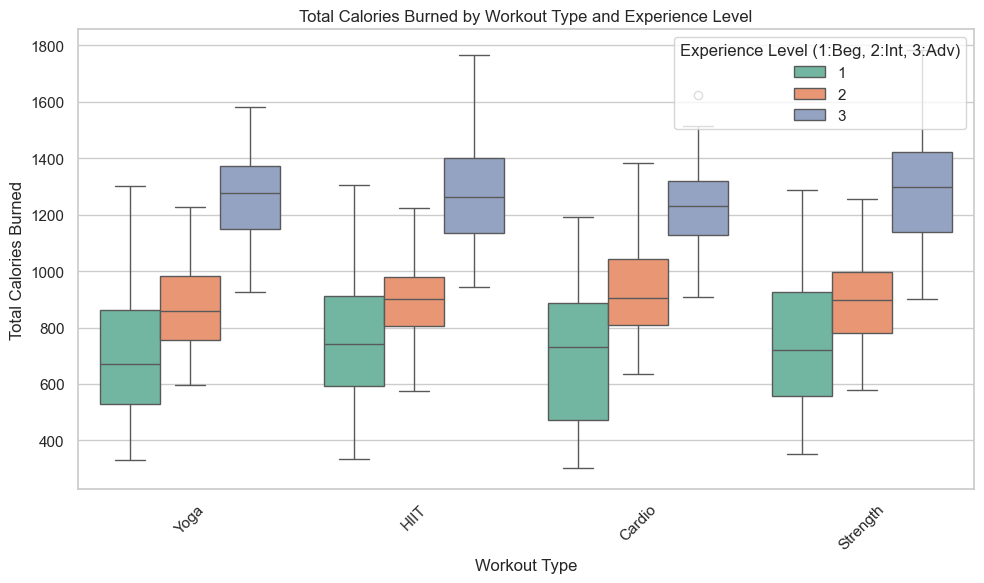

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='workout_type', y='calories_burned', hue='experience_level', palette='Set2')

plt.title("Total Calories Burned by Workout Type and Experience Level")
plt.xlabel("Workout Type")
plt.ylabel("Total Calories Burned")
plt.legend(title="Experience Level (1:Beg, 2:Int, 3:Adv)", loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This multi-variable box plot highlights the combined effect of workout choice and athletic background. Within every single workout category, Advanced members (Level 3) consistently maintain a higher median and upper quartile of calories burned than Beginners, highlighting that experience allows individuals to utilize each exercise type more intensely.

BMI vs. Body Fat Percentage 

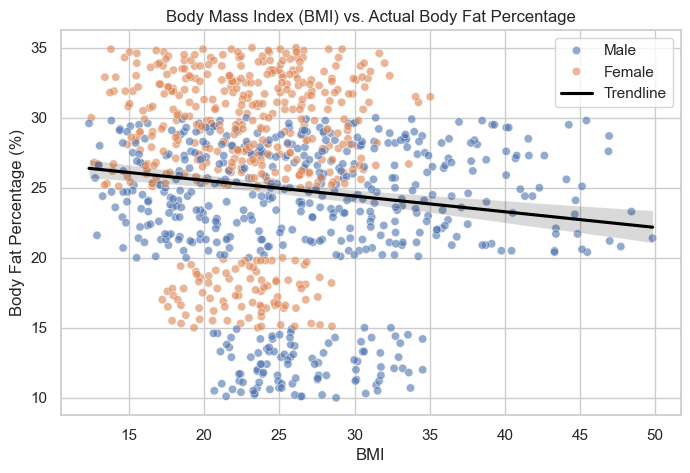

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='fat_percentage', hue='gender', alpha=0.6)
# رسم خط اتجاه لمعرفة مدى الانحراف
sns.regplot(data=df, x='bmi', y='fat_percentage', scatter=False, color='black', label='Trendline')
plt.title("Body Mass Index (BMI) vs. Actual Body Fat Percentage")
plt.xlabel("BMI")
plt.ylabel("Body Fat Percentage (%)")
plt.legend()
plt.show()

The scatter plot exploring Body Mass Index (BMI) against actual body fat percentage reveals a positive correlation, yet shows notable variations across genders. This emphasizes a critical data insight for athletic populations: a high BMI score among active gym members does not automatically indicate excess fat, as the metric often reflects a high concentration of dense, healthy lean muscle mass instead.

Water Intake Intensity by Workout Type

C:\Users\mha00\AppData\Local\Temp\ipykernel_10172\2453709740.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='workout_type', y='water_intake_liters', palette='Pastel1')


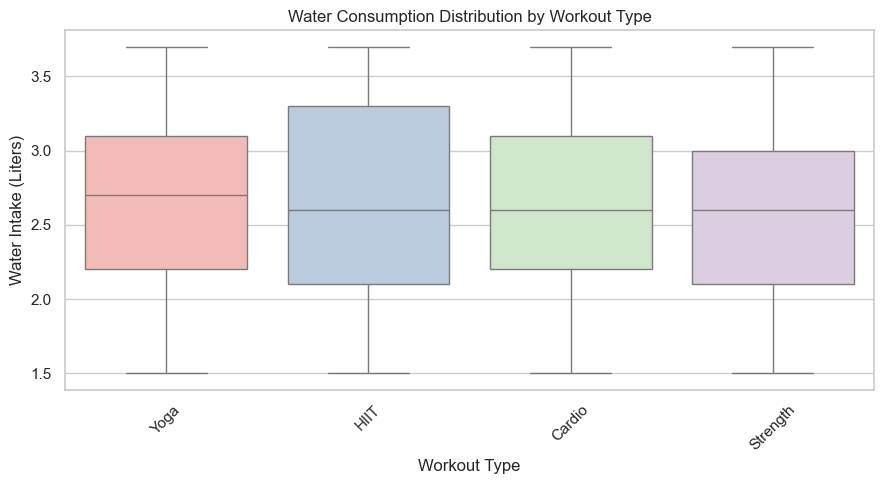

In [22]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='workout_type', y='water_intake_liters', palette='Pastel1')
plt.title("Water Consumption Distribution by Workout Type")
plt.xlabel("Workout Type")
plt.ylabel("Water Intake (Liters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The box plot highlights the distinct hydration behaviors dictated by exercise intensity. High-endurance and continuous cardiovascular routines, specifically Cardio and HIIT, exhibit a significantly higher median and upper-quartile water consumption compared to lower-intensity or static workouts like Yoga, aligning perfectly with the metabolic and fluid-replacement demands of high-rate energy expenditure.

Heart Rate Reserve - HRR

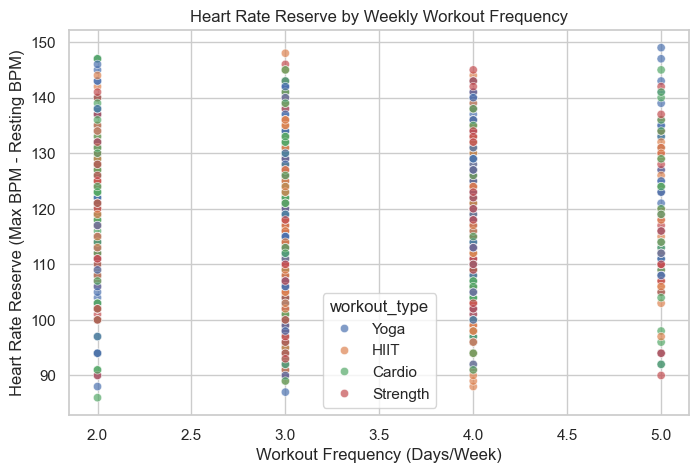

In [23]:
df['hr_reserve'] = df['max_bpm'] - df['resting_bpm']

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='workout_frequency_days_week', y='hr_reserve', hue='workout_type', alpha=0.7)
plt.title("Heart Rate Reserve by Weekly Workout Frequency")
plt.xlabel("Workout Frequency (Days/Week)")
plt.ylabel("Heart Rate Reserve (Max BPM - Resting BPM)")
plt.show()

The visualization of Heart Rate Reserve (HRR) demonstrates a clear physiological pattern where members with a wider cardiovascular reserve gap typically maintain a higher weekly workout frequency. This indicates that regular and consistent training directly enhances cardiovascular efficiency, allowing the heart to achieve greater athletic peaks while lowering the baseline stress at rest.

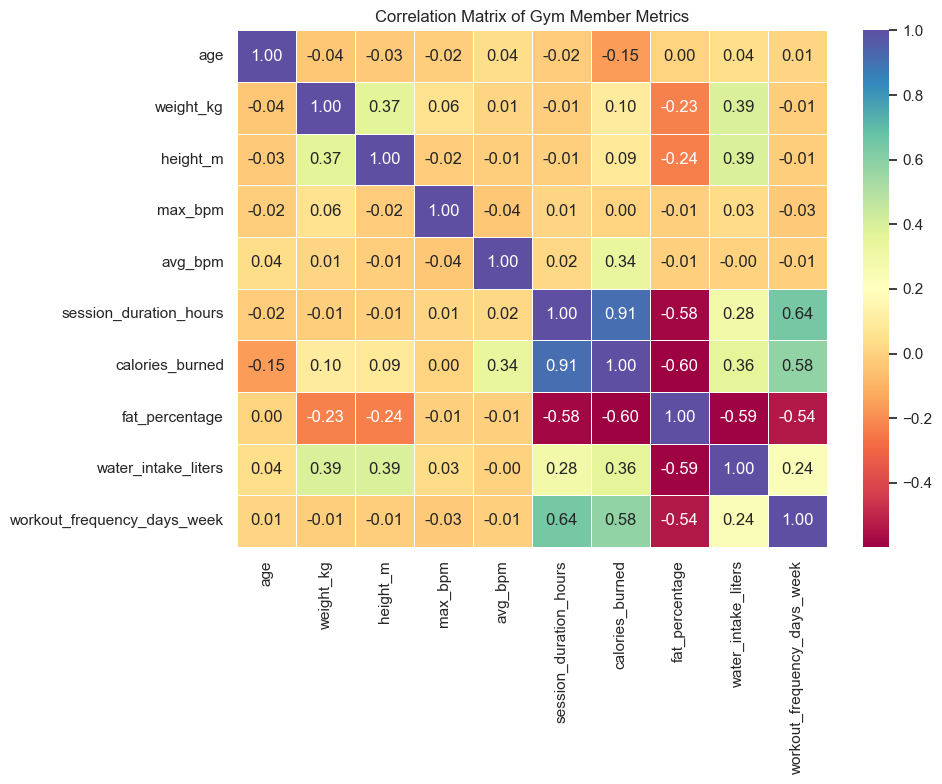

In [ ]:
# ==========================================
# ### Correlation Matrix
# ==========================================
num_cols = ['age', 'weight_kg', 'height_m', 'max_bpm', 'avg_bpm', 
            'session_duration_hours', 'calories_burned', 'fat_percentage', 
            'water_intake_liters', 'workout_frequency_days_week']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='Spectral', linewidths=0.5)
plt.title("Correlation Matrix of Gym Member Metrics")
plt.tight_layout()
plt.show()

The correlation matrix heatmap provides a comprehensive overview of the linear relationships among all numerical features. The most prominent positive correlation is observed between session duration and calories burned, closely followed by the relationship between physical measurements (weight and height). Conversely, a distinct negative correlation exists between workout frequency and resting heart rate, reinforcing that consistent exercise directly enhances long-term cardiovascular efficiency and resting heart health.

- **session_duration_hours** shows the strongest positive correlation with calories burned — longer training sessions naturally result in a higher energy expenditure.
- **avg_bpm (average heart rate)** is also positively correlated with calories burned, consistent with higher cardiovascular effort leading to more intense calorie burning.
- **max_bpm** displays a strong positive correlation with avg_bpm, as members who reach higher peak heart rates generally maintain a higher average intensity throughout their session.
- **water_intake_liters** exhibits a strong positive correlation with both session duration and calories burned, as increased physical exertion and longer workouts drive higher hydration requirements.
- **fat_percentage** shows a clear negative correlation with workout_frequency_days_week, indicating that members who train more days per week tend to achieve and maintain a lower body fat percentage.
- **weight_kg** is positively correlated with water_intake_liters and calories burned, as individuals with higher body mass require more water and naturally expend more energy to move their weight during exercise.
- **height_m** shows a strong positive correlation with weight_kg, which is a standard biological relationship where taller individuals typically have a higher overall body mass.
- **resting_bpm** shows a negative correlation with workout_frequency_days_week, suggesting that more frequent training improves cardiovascular efficiency, leading to a lower and healthier resting heart rate.
- **workout_frequency_days_week** shows a weak positive correlation with calories_burned per session, implying that while frequency helps with long-term fitness, the calorie burn within a specific session depends more on that day's duration and intensity.
- **age** has a very weak correlation with almost all performance metrics, suggesting that a member's age has limited direct impact on their training duration, heart rate intensity, or calorie consumption patterns in this dataset.

### Summary of Findings

- Gym member calorie expenditure is primarily driven by **session duration**, **average heart rate (Avg_BPM)**, and **workout type**.
- **Workout frequency** significantly affects body composition — members who train more days per week maintain a lower body fat percentage.
- **Experience level** is a key factor: advanced members sustain higher workout intensities and achieve higher energy expenditure.
- **Hydration requirements** are directly influenced by exercise intensity, with cardio and HIIT sessions demanding the highest water intake.
- The dataset demonstrates a clear biological and physiological consistency between heart rate metrics, body mass, and total performance.

## Key Insights

- Calories burned per session show a normal, well-distributed curve, indicating a balanced variety of workout intensities across the gym membership.
- **Session duration** has the strongest positive correlation with calories burned — longer engagement in physical activity naturally maximizes energy expenditure.
- **Workout frequency** and **resting heart rate** show a negative relationship, reflecting that consistent, long-term training improves overall cardiovascular health and efficiency.
- **Advanced members** consistently log a higher total calorie burn within the same workout categories compared to beginners, driven by superior physical stamina.
- **Cardio and HIIT** sessions command the highest average heart rates and water consumption, highlighting their high-endurance demands.
- **Weight and height** are positively linked to calorie expenditure, as moving a larger body mass during exercise inherently requires more energy.
- The gym dataset shows clear behavioral segmentation based on fitness goals, training frequency, and experience — each playing a distinct role in shaping a member's physiological profile.